In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Đọc và gộp 2 tập dữ liệu
df_mat = pd.read_csv('Data/student-mat.csv', sep=';')
df_por = pd.read_csv('Data/student-por.csv', sep=';')

df_mat['subject'] = 'Math'
df_por['subject'] = 'Por'
df = pd.concat([df_mat, df_por], ignore_index=True)

print(f"Sẵn sàng phân cụm {df.shape[0]} học sinh.")

Sẵn sàng phân cụm 1044 học sinh.


In [8]:
df_cluster = df.copy()

# Xử lý biến phân loại (Categorical)
categorical_cols = df_cluster.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df_cluster[col] = le.fit_transform(df_cluster[col])

# Bỏ các cột điểm số G1, G2, G3 ra khỏi dữ liệu huấn luyện. 
# Ta muốn phân nhóm học sinh hoàn toàn dựa trên "hoàn cảnh" và "hành vi", chứ không dựa trên "điểm số".
X = df_cluster.drop(['G1', 'G2', 'G3'], axis=1)

# BẮT BUỘC: Chuẩn hóa dữ liệu cho K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Đã chuẩn hóa xong dữ liệu!")

Đã chuẩn hóa xong dữ liệu!


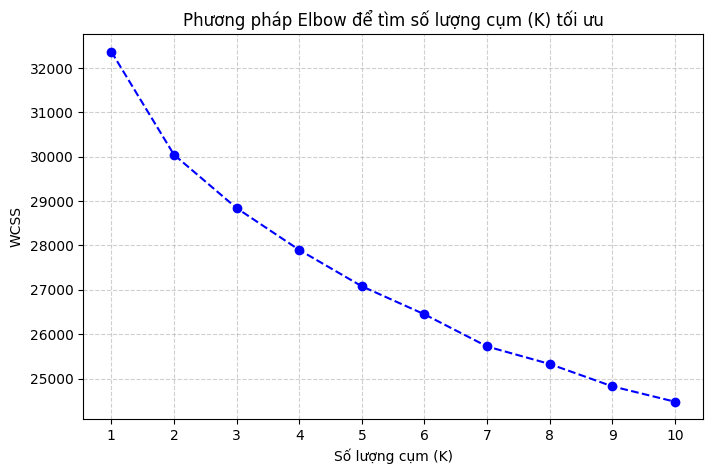

In [9]:
wcss = [] # Within-Cluster Sum of Square (Tổng bình phương khoảng cách trong cụm)

# Thử nghiệm K từ 1 đến 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Phương pháp Elbow để tìm số lượng cụm (K) tối ưu')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
# Khởi tạo và chạy K-Means với K=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Gắn số thứ tự cụm (0, 1, 2) ngược lại vào tệp dữ liệu gốc (chưa mã hóa) để dễ đọc hiểu
df['Cluster'] = clusters

print("Số lượng học sinh trong từng nhóm:")
print(df['Cluster'].value_counts())

Số lượng học sinh trong từng nhóm:
Cluster
1    507
2    323
0    214
Name: count, dtype: int64


In [11]:
# Nhóm dữ liệu theo Cluster và tính trung bình các cột quan trọng
# Ghi chú: G3 (Điểm), absences (Nghỉ học), studytime (Học ở nhà), goout (Đi chơi), Walc (Uống rượu cuối tuần)
cluster_analysis = df.groupby('Cluster')[['G3', 'absences', 'studytime', 'goout', 'Walc']].mean()

print("Đặc điểm trung bình của từng nhóm học sinh:")
display(cluster_analysis.round(2))

Đặc điểm trung bình của từng nhóm học sinh:


,G3,absences,studytime,goout,Walc
Cluster,,,,,
0,9.59,6.13,1.54,3.94,3.84
1,12.33,4.15,2.16,2.98,1.95
2,10.95,3.76,1.96,2.91,1.77


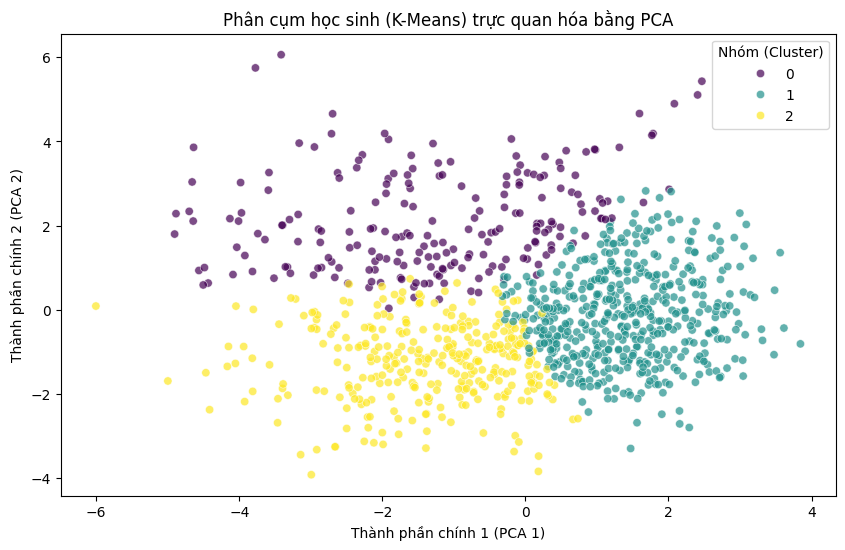

In [12]:
# Nén dữ liệu xuống 2 chiều
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Vẽ biểu đồ Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='viridis', alpha=0.7)

plt.title('Phân cụm học sinh (K-Means) trực quan hóa bằng PCA')
plt.xlabel('Thành phần chính 1 (PCA 1)')
plt.ylabel('Thành phần chính 2 (PCA 2)')
plt.legend(title='Nhóm (Cluster)')
plt.show()